# GTSRB Traffic Sign Subset (Classes 0–8, 33–40)

This notebook helps you prepare the dataset and verify the filtered subset.

In [5]:
import kagglehub
import pandas as pd
import shutil
from pathlib import Path

# Required classes only
REQUIRED_CLASSES = [0, 1, 2, 3, 4, 5, 6, 7, 8, 33, 34, 35, 36, 37, 38, 39, 40]

# Download dataset
dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"Downloaded to: {dataset_path}")

# Find CSV files
root = Path(dataset_path)
print(f"Searching for CSV files in: {root}")
print(f"Directory contents: {[item.name for item in root.iterdir()]}")

# Correctly find the CSV files
train_csv = root / 'Train.csv'
test_csv = root / 'Test.csv'

print(f"Found train CSV: {train_csv}")
print(f"Found test CSV: {test_csv}")

# Filter and copy only required classes
def filter_classes(csv_path, split_name):
    df = pd.read_csv(csv_path, delimiter=',') # Changed delimiter to comma
    filtered = df[df['ClassId'].isin(REQUIRED_CLASSES)]

    out_dir = Path("model_data") / split_name
    count = 0

    for _, row in filtered.iterrows():
        class_id = row['ClassId']
        img_path = root / row['Path']

        if img_path.exists():
            dest_dir = out_dir / str(class_id)
            dest_dir.mkdir(parents=True, exist_ok=True)

            dest_file = dest_dir / img_path.name
            if not dest_file.exists():
                shutil.copy2(img_path, dest_file)
                count += 1

    print(f"{split_name}: {count} images copied")

# Copy only required classes
filter_classes(train_csv, 'train')
filter_classes(test_csv, 'test')

print("Done! Data ready in model_data/")

Downloaded to: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1
Searching for CSV files in: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1
Directory contents: ['test', 'meta', 'Meta.csv', 'train', 'Test', 'Train', 'Meta', 'Train.csv', 'Test.csv']
Found train CSV: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Train.csv
Found test CSV: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Test.csv
train: 18839 images copied
test: 6090 images copied
Done! Data ready in model_data/


Using device: cuda
Class distribution:
  Class 0: 210 samples
  Class 1: 2220 samples
  Class 2: 2250 samples
  Class 3: 1410 samples
  Class 33: 689 samples
  Class 34: 420 samples
  Class 35: 1200 samples
  Class 36: 390 samples
  Class 37: 210 samples
  Class 38: 2070 samples
  Class 39: 300 samples
  Class 4: 1980 samples
  Class 40: 360 samples
  Class 5: 1860 samples
  Class 6: 420 samples
  Class 7: 1440 samples
  Class 8: 1410 samples

Dataset Summary:
Train samples: 18839
Test samples: 6090
Number of classes: 17
Classes: ['0', '1', '2', '3', '33', '34', '35', '36', '37', '38', '39', '4', '40', '5', '6', '7', '8']
Batch size: 64
Using balanced sampling: Yes

Sample images from dataset:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


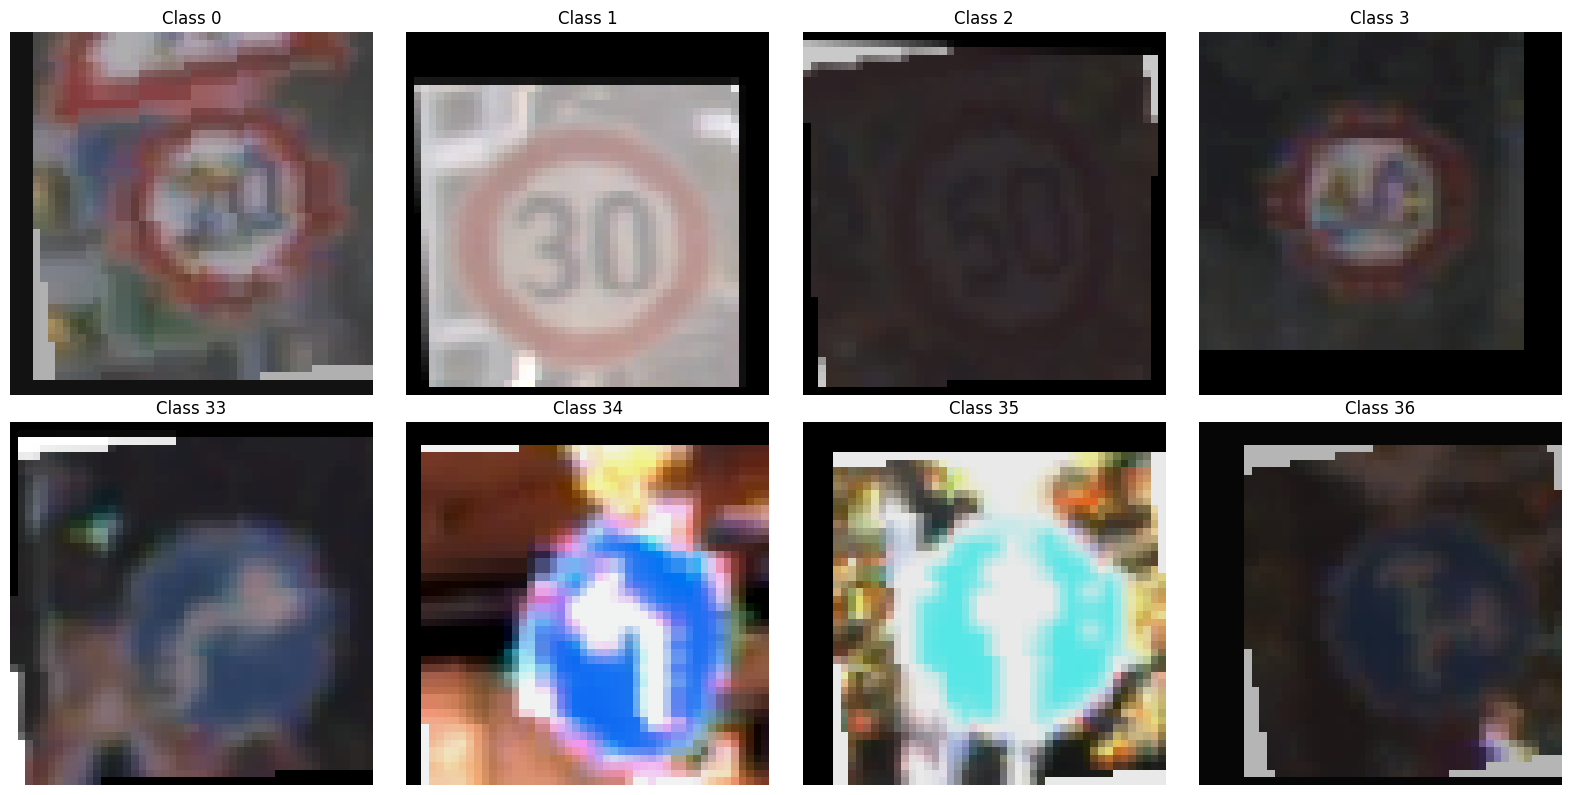

In [8]:
  ## 3) Load and preprocess image data - IMPROVED

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from pathlib import Path
from collections import Counter

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Data paths
train_dir = Path("model_data/train")
test_dir = Path("model_data/test")

# IMPROVED Image transformations
train_transform = transforms.Compose([
    transforms.Resize((48, 48)),  # Larger size for better features
    transforms.RandomRotation(15, fill=255),  # White fill for traffic signs
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation augmentation (lighter)
val_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

# CLASS BALANCING - Handle imbalanced data
def get_class_weights(dataset):
    """Calculate weights for balanced sampling"""
    targets = [dataset[i][1] for i in range(len(dataset))]
    class_counts = Counter(targets)
    total_samples = len(targets)

    # Calculate weights inversely proportional to class frequency
    class_weights = {cls: total_samples / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[target] for target in targets]

    print("Class distribution:")
    for cls, count in sorted(class_counts.items()):
        print(f"  Class {train_dataset.classes[cls]}: {count} samples")

    return torch.DoubleTensor(sample_weights)

# Create balanced sampler
sample_weights = get_class_weights(train_dataset)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# IMPROVED Data loaders
batch_size = 64  # Increased batch size
num_workers = 4 if torch.cuda.is_available() else 2

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,  # Use balanced sampler instead of shuffle
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\nDataset Summary:")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")
print(f"Batch size: {batch_size}")
print(f"Using balanced sampling: Yes")

# VISUALIZATION - Show sample images
def show_sample_images(dataset, num_samples=8):
    """Display sample images from each class"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    # Get one sample from each class (up to 8)
    class_samples = {}
    for i, (img, label) in enumerate(dataset):
        if label not in class_samples and len(class_samples) < num_samples:
            class_samples[label] = (img, label)
        if len(class_samples) >= num_samples:
            break

    for idx, (label, (img, _)) in enumerate(class_samples.items()):
        # Denormalize image for display
        img_denorm = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_denorm += torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img_denorm = torch.clamp(img_denorm, 0, 1)

        axes[idx].imshow(img_denorm.permute(1, 2, 0))
        axes[idx].set_title(f'Class {dataset.classes[label]}')
        axes[idx].axis('off')

    # Hide unused subplots
    for idx in range(len(class_samples), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# Show sample images
print("\nSample images from dataset:")
show_sample_images(train_dataset)

In [10]:
## 4) ResNet Model for Traffic Sign Classification

import torchvision.models as models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from pathlib import Path
from collections import Counter

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Data paths
train_dir = Path("model_data/train")
test_dir = Path("model_data/test")


class ResNetTrafficSign(nn.Module):
    def __init__(self, num_classes=17):
        super(ResNetTrafficSign, self).__init__()

        # Use pretrained ResNet18 as backbone
        self.backbone = models.resnet18(pretrained=True)

        # Modify first conv layer for 32x32 input (small traffic sign images)
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.backbone.maxpool = nn.Identity()  # Remove maxpool for small images

        # Replace final layer with custom classifier
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

        # Optionally freeze early layers for transfer learning
        self._freeze_early_layers()

        # Initialize new layers
        self._initialize_new_layers()

    def _freeze_early_layers(self, freeze=True):
        """Freeze early layers to use as feature extractor"""
        if freeze:
            # Freeze conv1, bn1, and first few residual blocks
            for param in self.backbone.conv1.parameters():
                param.requires_grad = False
            for param in self.backbone.bn1.parameters():
                param.requires_grad = False
            for param in self.backbone.layer1.parameters():
                param.requires_grad = False
            # Optionally freeze layer2 as well
            # for param in self.backbone.layer2.parameters():
            #     param.requires_grad = False

    def _initialize_new_layers(self):
        """Initialize the new classifier layers"""
        for module in self.backbone.fc.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.BatchNorm1d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        return self.backbone(x)

# Enhanced data augmentation for ResNet
train_transform = transforms.Compose([
    transforms.Resize((40, 40)),  # Slightly larger for random crop
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.15))
])

# Validation/Test augmentation
test_transform = transforms.Compose([
    transforms.Resize((32, 32)), # Resize to match expected model input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Update datasets with enhanced transforms
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

# Re-calculate class weights and sampler due to new dataset object
def get_class_weights(dataset):
    """Calculate weights for balanced sampling"""
    targets = [dataset[i][1] for i in range(len(dataset))]
    class_counts = Counter(targets)
    total_samples = len(targets)

    # Calculate weights inversely proportional to class frequency
    class_weights = {cls: total_samples / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[target] for target in targets]

    print("Class distribution:")
    for cls, count in sorted(class_counts.items()):
        print(f"  Class {dataset.classes[cls]}: {count} samples")

    return torch.DoubleTensor(sample_weights)

sample_weights = get_class_weights(train_dataset)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))


# IMPROVED Data loaders - Use re-calculated sampler for train_loader
batch_size = 64
num_workers = 4 if torch.cuda.is_available() else 2 # Ensure num_workers is defined

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,  # Use balanced sampler instead of shuffle
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)


# Initialize ResNet model
num_classes = len(train_dataset.classes) # Ensure num_classes is defined
model = ResNetTrafficSign(num_classes=num_classes).to(device)


# Enhanced loss function with label smoothing
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        n_class = pred.size(1)
        one_hot = torch.zeros_like(pred).scatter(1, target.view(-1, 1), 1)
        one_hot = one_hot * (1 - self.smoothing) + (1 - one_hot) * self.smoothing / (n_class - 1)
        log_prob = torch.nn.functional.log_softmax(pred, dim=1)
        return -(one_hot * log_prob).sum(dim=1).mean()

# Setup training components
criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# OneCycleLR scheduler for better convergence
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,
    steps_per_epoch=len(train_loader),
    epochs=25,
    pct_start=0.3,
    div_factor=10,
    final_div_factor=100
)

print(f"ResNet model initialized with {num_classes} classes")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cuda
Class distribution:
  Class 0: 210 samples
  Class 1: 2220 samples
  Class 2: 2250 samples
  Class 3: 1410 samples
  Class 33: 689 samples
  Class 34: 420 samples
  Class 35: 1200 samples
  Class 36: 390 samples
  Class 37: 210 samples
  Class 38: 2070 samples
  Class 39: 300 samples
  Class 4: 1980 samples
  Class 40: 360 samples
  Class 5: 1860 samples
  Class 6: 420 samples
  Class 7: 1440 samples
  Class 8: 1410 samples
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNe

ResNet model initialized with 17 classes
Model parameters: 11,336,017
Trainable parameters: 11,186,193


In [13]:
## 5) Enhanced Training Function

import time
from tqdm import tqdm

def train_model_enhanced(model, train_loader, test_loader, criterion, optimizer, scheduler,
                        num_epochs=25, early_stopping_patience=7, save_best=True):
    """
    Enhanced training function with early stopping, best model saving, and detailed metrics
    """
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []
    learning_rates = []

    best_test_acc = 0.0
    patience_counter = 0
    start_time = time.time()

    print(f"Training for {num_epochs} epochs with early stopping patience: {early_stopping_patience}")
    print("-" * 70)

    for epoch in range(num_epochs):
        epoch_start_time = time.time()

        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        # Progress bar for training
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]',
                         leave=False, disable=False)

        for batch_idx, (images, labels) in enumerate(train_pbar):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # Update scheduler if using OneCycleLR
            if isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
                scheduler.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            # Update progress bar
            current_acc = 100 * correct_train / total_train
            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{current_acc:.2f}%',
                'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
            })

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            val_pbar = tqdm(test_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]',
                           leave=False, disable=False)

            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

                # Update progress bar
                current_val_acc = 100 * correct_test / total_test
                val_pbar.set_postfix({
                    'Loss': f'{loss.item():.4f}',
                    'Acc': f'{current_val_acc:.2f}%'
                })

        # Calculate epoch metrics
        epoch_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        val_loss = val_running_loss / len(test_loader)
        test_acc = 100 * correct_test / total_test
        current_lr = optimizer.param_groups[0]['lr']

        # Store metrics
        train_losses.append(epoch_loss)
        train_accuracies.append(train_acc)
        test_losses.append(val_loss)
        test_accuracies.append(test_acc)
        learning_rates.append(current_lr)

        # Update scheduler (for non-OneCycleLR schedulers)
        if not isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Calculate epoch time
        epoch_time = time.time() - epoch_start_time

        # Print epoch summary
        print(f'Epoch [{epoch+1:2d}/{num_epochs}] | '
              f'Train Loss: {epoch_loss:.4f} | Train Acc: {train_acc:6.2f}% | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {test_acc:6.2f}% | '
              f'LR: {current_lr:.6f} | Time: {epoch_time:.1f}s')

        # Early stopping and best model saving
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            patience_counter = 0

            if save_best:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'best_acc': best_test_acc,
                    'train_losses': train_losses,
                    'train_accuracies': train_accuracies,
                    'test_losses': test_losses,
                    'test_accuracies': test_accuracies,
                    'class_to_idx': train_loader.dataset.class_to_idx,
                }, 'best_model_checkpoint.pth')
                print(f'✓ New best model saved! Val Acc: {best_test_acc:.2f}%')
        else:
            patience_counter += 1

        # Early stopping check
        if patience_counter >= early_stopping_patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs')
            print(f'Best validation accuracy: {best_test_acc:.2f}%')
            break

        print("-" * 70)

    total_time = time.time() - start_time
    print(f'\nTraining completed in {total_time/60:.1f} minutes')
    print(f'Best validation accuracy: {best_test_acc:.2f}%')

    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'test_losses': test_losses,
        'test_accuracies': test_accuracies,
        'learning_rates': learning_rates,
        'best_accuracy': best_test_acc,
        'total_epochs': len(train_losses)
    }

# Enhanced model setup with better optimizer and scheduler
model = ResNetTrafficSign(num_classes=num_classes).to(device) # Corrected model name

# Better optimizer with weight decay
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4, betas=(0.9, 0.999))

# Better scheduler - ReduceLROnPlateau for adaptive learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

# Enhanced loss function with label smoothing
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        n_class = pred.size(1)
        one_hot = torch.zeros_like(pred).scatter(1, target.view(-1, 1), 1)
        one_hot = one_hot * (1 - self.smoothing) + (1 - one_hot) * self.smoothing / (n_class - 1)
        log_prob = torch.nn.functional.log_softmax(pred, dim=1)
        return -(one_hot * log_prob).sum(dim=1).mean()

criterion = LabelSmoothingCrossEntropy(smoothing=0.1)

print(f"Enhanced model setup complete!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Train the model with enhanced function
print("\nStarting enhanced training...")
training_results = train_model_enhanced(
    model, train_loader, test_loader, criterion, optimizer, scheduler,
    num_epochs=30, early_stopping_patience=7, save_best=True
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Enhanced model setup complete!
Model parameters: 11,336,017

Starting enhanced training...
Training for 30 epochs with early stopping patience: 7
----------------------------------------------------------------------


Epoch 1/30 [Train]:   0%|          | 0/295 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch [ 1/30] | Train Loss: 1.7258 | Train Acc:  57.67% | Val Loss: 1.0606 | Val Acc:  83.73% | LR: 0.001000 | Time: 36.5s
✓ New best model saved! Val Acc: 83.73%
----------------------------------------------------------------------


Epoch [ 2/30] | Train Loss: 0.8608 | Train Acc:  92.35% | Val Loss: 0.7789 | Val Acc:  94.48% | LR: 0.001000 | Time: 34.7s
✓ New best model saved! Val Acc: 94.48%
----------------------------------------------------------------------


...

Epoch [26/30] | Train Loss: 0.6317 | Train Acc:  99.42% | Val Loss: 0.6523 | Val Acc:  98.49% | LR: 0.000250 | Time: 36.0s
----------------------------------------------------------------------


Epoch [27/30] | Train Loss: 0.6350 | Train Acc:  99.26% | Val Loss: 0.6575 | Val Acc:  98.18% | LR: 0.000250 | Time: 35.9s
----------------------------------------------------------------------


Epoch [28/30] | Train Loss: 0.6329 | Train Acc:  99.33% | Val Loss: 0.6564 | Val Acc:  98.31% | LR: 0.000250 | Time: 36.4s
----------------------------------------------------------------------


Epoch [29/30] | Train Loss: 0.6349 | Train Acc:  99.32% | Val Loss: 0.6640 | Val Acc:  98.19% | LR: 0.000250 | Time: 35.1s
----------------------------------------------------------------------


Epoch [30/30] | Train Loss: 0.6350 | Train Acc:  99.23% | Val Loss: 0.6557 | Val Acc:  98.42% | LR: 0.000125 | Time: 36.5s

Early stopping triggered after 30 epochs
Best validation accuracy: 98.49%

Training completed in 18.8 minutes
Best validation accuracy: 98.49%


Evaluating Model:   0%|          | 0/96 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Evaluating Model: 100%|██████████| 96/96 [00:03<00:00, 27.99it/s]


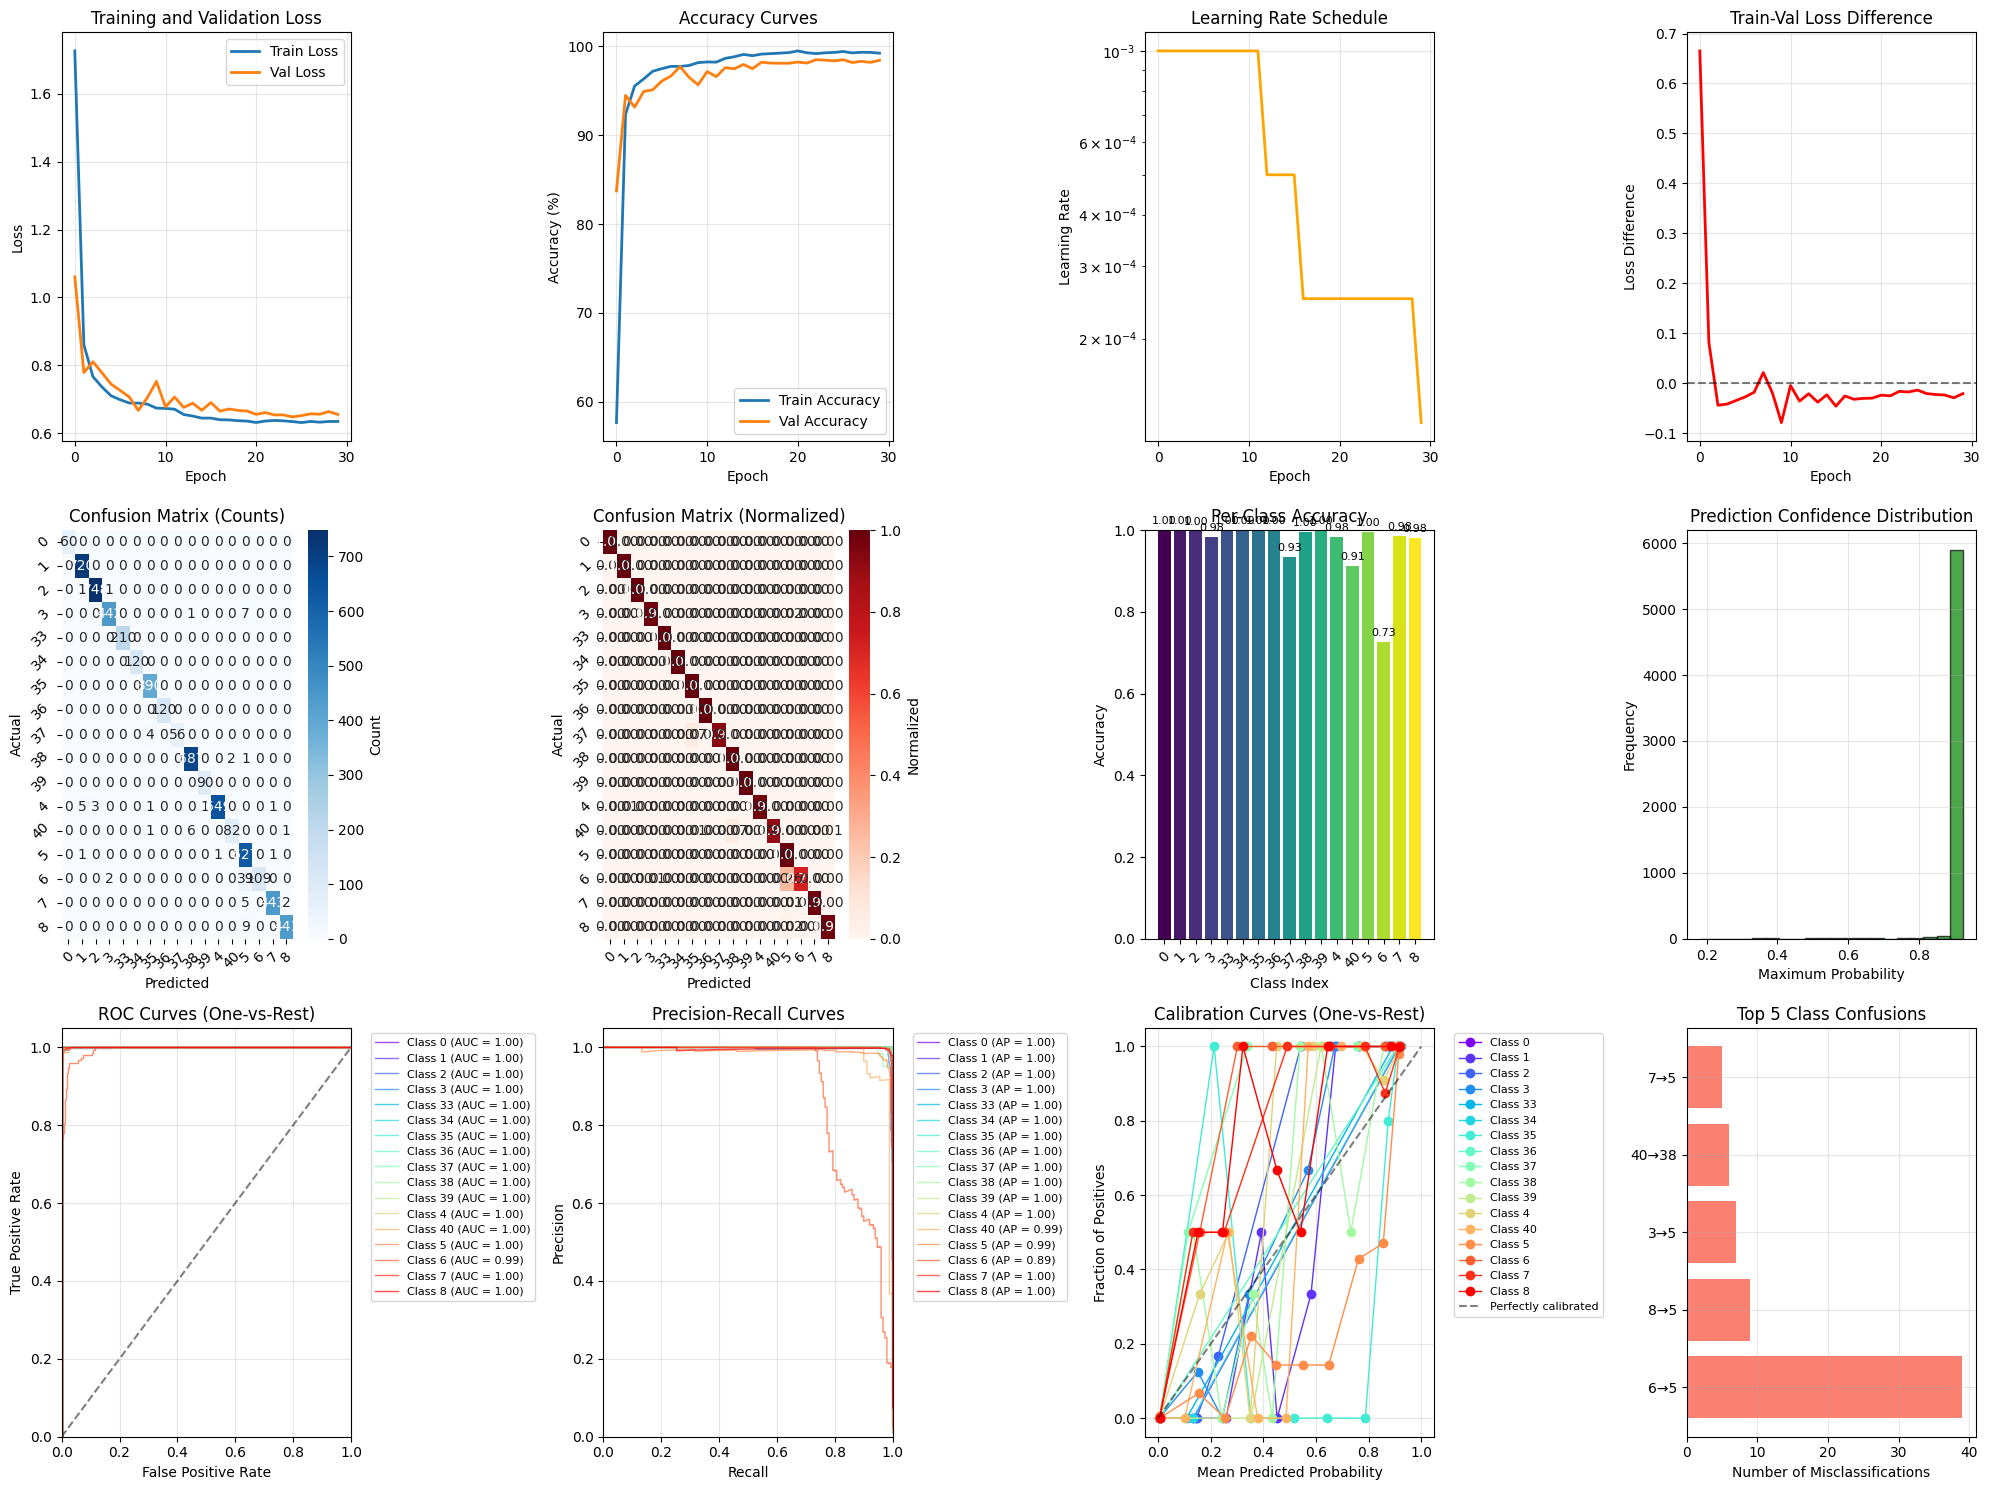


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        60
     Class 1       0.99      1.00      1.00       720
     Class 2       1.00      1.00      1.00       750
     Class 3       0.99      0.98      0.99       450
    Class 33       1.00      1.00      1.00       210
    Class 34       1.00      1.00      1.00       120
    Class 35       0.98      1.00      0.99       390
    Class 36       1.00      1.00      1.00       120
    Class 37       1.00      0.93      0.97        60
    Class 38       0.99      1.00      0.99       690
    Class 39       0.99      1.00      0.99        90
     Class 4       1.00      0.98      0.99       660
    Class 40       0.98      0.91      0.94        90
     Class 5       0.91      1.00      0.95       630
     Class 6       1.00      0.73      0.84       150
     Class 7       1.00      0.98      0.99       450
     Class 8       0.99      0.98      0.99       450

   

In [15]:
## 6) Enhanced Evaluation and Visualization

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Extract results from training
train_losses = training_results['train_losses']
train_accs = training_results['train_accuracies']
test_losses = training_results['test_losses']
test_accs = training_results['test_accuracies']
num_classes = len(train_dataset.classes)


# Enhanced plotting with more subplots
plt.figure(figsize=(20, 15))

# Training curves
plt.subplot(3, 4, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Val Loss', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 4, 2)
plt.plot(train_accs, label='Train Accuracy', linewidth=2)
plt.plot(test_accs, label='Val Accuracy', linewidth=2)
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Learning rate schedule
plt.subplot(3, 4, 3)
plt.plot(training_results['learning_rates'], linewidth=2, color='orange')
plt.title('Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.yscale('log')
plt.grid(True, alpha=0.3)

# Loss difference
plt.subplot(3, 4, 4)
loss_diff = np.array(train_losses) - np.array(test_losses)
plt.plot(loss_diff, linewidth=2, color='red')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Train-Val Loss Difference')
plt.xlabel('Epoch')
plt.ylabel('Loss Difference')
plt.grid(True, alpha=0.3)

# Final evaluation with progress bar
model.eval()
all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating Model'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)

# Confusion matrix with better visualization
plt.subplot(3, 4, 5)
cm = confusion_matrix(all_labels, all_predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (Counts)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.subplot(3, 4, 6)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes,
            cbar_kws={'label': 'Normalized'})
plt.title('Confusion Matrix (Normalized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)

# Per-class accuracy
plt.subplot(3, 4, 7)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
bars = plt.bar(range(len(class_accuracies)), class_accuracies,
               color=plt.cm.viridis(np.linspace(0, 1, len(class_accuracies))))
plt.title('Per-Class Accuracy')
plt.xlabel('Class Index')
plt.ylabel('Accuracy')
plt.xticks(range(len(train_dataset.classes)), train_dataset.classes, rotation=45)
plt.ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, class_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2f}', ha='center', va='bottom', fontsize=8)

# Prediction confidence distribution
plt.subplot(3, 4, 8)
max_probs = np.max(all_probabilities, axis=1)
plt.hist(max_probs, bins=20, alpha=0.7, color='green', edgecolor='black')
plt.title('Prediction Confidence Distribution')
plt.xlabel('Maximum Probability')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# ROC curves for multi-class (one-vs-rest)
plt.subplot(3, 4, 9)
# Binarize labels for multi-class ROC
y_bin = label_binarize(all_labels, classes=range(num_classes))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC for each class
colors = plt.cm.rainbow(np.linspace(0, 1, num_classes))
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, alpha=0.7, linewidth=1,
             label=f'Class {train_dataset.classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

# Precision-Recall curves
plt.subplot(3, 4, 10)
from sklearn.metrics import precision_recall_curve, average_precision_score

precision = dict()
recall = dict()
average_precision = dict()

for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_bin[:, i], all_probabilities[:, i])
    average_precision[i] = average_precision_score(y_bin[:, i], all_probabilities[:, i])

for i, color in zip(range(num_classes), colors):
    plt.plot(recall[i], precision[i], color=color, alpha=0.7, linewidth=1,
             label=f'Class {train_dataset.classes[i]} (AP = {average_precision[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curves')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

# Model calibration plots (One-vs-Rest)
plt.subplot(3, 4, 11)
from sklearn.calibration import calibration_curve

# Plot calibration curves for each class
for i, color in zip(range(num_classes), colors):
    prob_true, prob_pred = calibration_curve(y_bin[:, i], all_probabilities[:, i], n_bins=10, strategy='uniform')
    plt.plot(prob_pred, prob_true, marker='o', linewidth=1, color=color,
             label=f'Class {train_dataset.classes[i]}')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves (One-vs-Rest)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)


# Error analysis - most confused classes
plt.subplot(3, 4, 12)
# Find most confused pairs
confusions = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            confusions.append((cm[i, j], i, j))

confusions.sort(reverse=True)
top_confusions = confusions[:5]  # Top 5 confusions

confusion_labels = [f'{train_dataset.classes[i]}→{train_dataset.classes[j]}' for count, i, j in top_confusions]
confusion_counts = [count for count, _, _ in top_confusions]

plt.barh(confusion_labels, confusion_counts, color='salmon')
plt.title('Top 5 Class Confusions')
plt.xlabel('Number of Misclassifications')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Enhanced classification report
class_names = [f"Class {cls}" for cls in train_dataset.classes]
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(all_labels, all_predictions, target_names=class_names))

# Additional metrics
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_predictions, average=None)

print("\n" + "="*80)
print("DETAILED METRICS BY CLASS")
print("="*80)
for i, class_name in enumerate(class_names):
    print(f"{class_name:15} | Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f} | Support: {support[i]}")

# Overall metrics
macro_avg = precision_recall_fscore_support(all_labels, all_predictions, average='macro')
weighted_avg = precision_recall_fscore_support(all_labels, all_predictions, average='weighted')

print("\n" + "="*80)
print("OVERALL METRICS")
print("="*80)
print(f"Macro Average    | Precision: {macro_avg[0]:.3f} | Recall: {macro_avg[1]:.3f} | F1: {macro_avg[2]:.3f}")
print(f"Weighted Average | Precision: {weighted_avg[0]:.3f} | Recall: {weighted_avg[1]:.3f} | F1: {weighted_avg[2]:.3f}")

final_accuracy = accuracy_score(all_labels, all_predictions)
print(f"\nFinal Test Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")

# Model confidence analysis
mean_confidence = np.mean(max_probs)
std_confidence = np.std(max_probs)
print(f"Mean Prediction Confidence: {mean_confidence:.4f} ± {std_confidence:.4f}")

# Save detailed results
results_dict = {
    'final_accuracy': final_accuracy,
    'confusion_matrix': cm,
    'classification_report': classification_report(all_labels, all_predictions, target_names=class_names, output_dict=True),
    'per_class_accuracy': class_accuracies,
    'training_results': training_results,
    'predictions': all_predictions,
    'labels': all_labels,
    'probabilities': all_probabilities
}

torch.save(results_dict, 'evaluation_results.pth')
print("\nDetailed evaluation results saved to 'evaluation_results.pth'")
print("Enhanced evaluation and visualization complete!")

🎯 Enhanced model saved as: traffic_sign_model_enhanced_20250919_163423.pth
📄 Metadata saved as: traffic_sign_model_metadata_20250919_163423.json


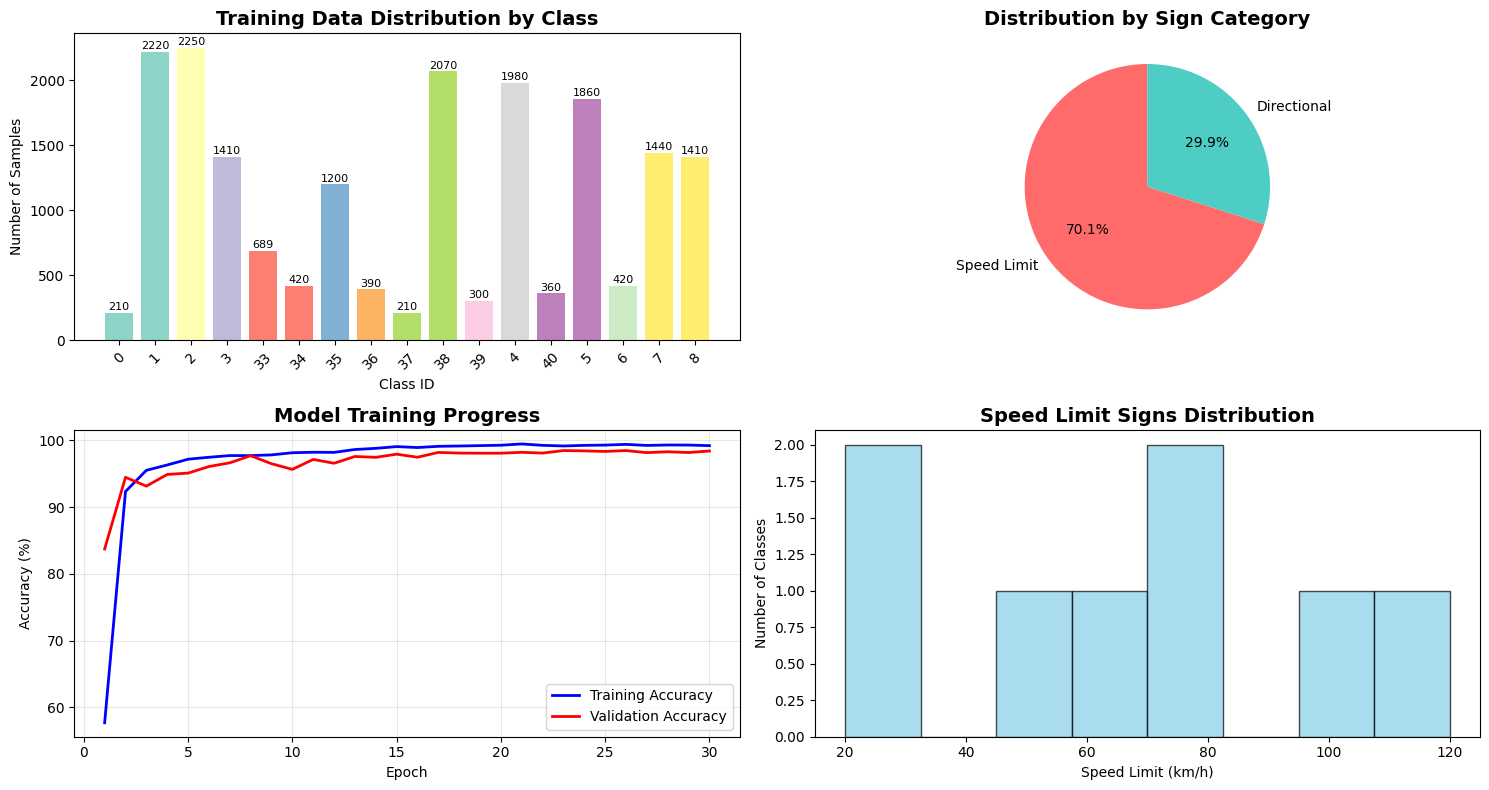


🚦 TRAFFIC SIGN CLASSIFICATION MODEL SUMMARY

📊 MODEL STATISTICS:
   • Total Parameters: 11,336,017
   • Best Validation Accuracy: 98.49%
   • Training Device: cuda
   • Total Training Epochs: 30

📈 DATASET INFORMATION:
   • Training Samples: 18,839
   • Test Samples: 6,090
   • Number of Classes: 17

🏷️  DETAILED CLASS MAPPING:
--------------------------------------------------------------------------------
Index  Class ID   Sign Name                           Category        Samples 
--------------------------------------------------------------------------------
0      0          Speed limit (20 km/h)               Speed Limit     210     
1      1          Speed limit (30 km/h)               Speed Limit     2220    
2      2          Speed limit (50 km/h)               Speed Limit     2250    
3      3          Speed limit (60 km/h)               Speed Limit     1410    
4      33         Turn right ahead                    Directional     689     
5      34         Turn left ahead

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded successfully!

🎉 Enhanced model saving and analysis complete!


In [18]:
## Cell 7: Enhanced Model Saving and Analysis

import json
import os
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Create timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Enhanced class mapping with additional metadata
class_mapping = {
    '0': {'name': 'Speed limit (20 km/h)', 'category': 'Speed Limit', 'max_speed': 20},
    '1': {'name': 'Speed limit (30 km/h)', 'category': 'Speed Limit', 'max_speed': 30},
    '2': {'name': 'Speed limit (50 km/h)', 'category': 'Speed Limit', 'max_speed': 50},
    '3': {'name': 'Speed limit (60 km/h)', 'category': 'Speed Limit', 'max_speed': 60},
    '4': {'name': 'Speed limit (70 km/h)', 'category': 'Speed Limit', 'max_speed': 70},
    '5': {'name': 'Speed limit (80 km/h)', 'category': 'Speed Limit', 'max_speed': 80},
    '6': {'name': 'End of speed limit (80 km/h)', 'category': 'Speed Limit', 'max_speed': None},
    '7': {'name': 'Speed limit (100 km/h)', 'category': 'Speed Limit', 'max_speed': 100},
    '8': {'name': 'Speed limit (120 km/h)', 'category': 'Speed Limit', 'max_speed': 120},
    '33': {'name': 'Turn right ahead', 'category': 'Directional', 'max_speed': None},
    '34': {'name': 'Turn left ahead', 'category': 'Directional', 'max_speed': None},
    '35': {'name': 'Ahead only', 'category': 'Directional', 'max_speed': None},
    '36': {'name': 'Go straight or right', 'category': 'Directional', 'max_speed': None},
    '37': {'name': 'Go straight or left', 'category': 'Directional', 'max_speed': None},
    '38': {'name': 'Keep right', 'category': 'Directional', 'max_speed': None},
    '39': {'name': 'Keep left', 'category': 'Directional', 'max_speed': None},
    '40': {'name': 'Roundabout mandatory', 'category': 'Directional', 'max_speed': None}
}

# Create comprehensive model metadata
model_metadata = {
    'model_info': {
        'model_name': 'TrafficSignCNN',
        'num_classes': num_classes,
        'total_parameters': sum(p.numel() for p in model.parameters()),
        'trainable_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad),
        'input_size': (3, 32, 32),
        'architecture': 'Custom CNN with 4 conv layers + 3 FC layers'
    },
    'training_info': {
        'final_train_accuracy': training_results['train_accuracies'][-1],
        'final_val_accuracy': training_results['test_accuracies'][-1],
        'best_accuracy': training_results['best_accuracy'],
        'total_epochs_trained': training_results['total_epochs'],
        'device_used': str(device),
        'batch_size': batch_size,
        'optimizer': 'AdamW',
        'scheduler': 'OneCycleLR',
        'loss_function': 'LabelSmoothingCrossEntropy'
    },
    'dataset_info': {
        'train_samples': len(train_dataset),
        'test_samples': len(test_dataset),
        'classes': train_dataset.classes,
        'class_to_idx': train_dataset.class_to_idx,
        'idx_to_class': {v: k for k, v in train_dataset.class_to_idx.items()}
    },
    'class_mapping': class_mapping,
    'timestamp': timestamp,
    'pytorch_version': torch.__version__
}

# Enhanced model saving with comprehensive metadata
enhanced_model_path = f'traffic_sign_model_enhanced_{timestamp}.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_metadata': model_metadata,
    'training_results': training_results,
    'model_architecture': str(model),
    'optimizer_state_dict': optimizer.state_dict(),
    'criterion_state_dict': criterion.state_dict() if hasattr(criterion, 'state_dict') else None,
}, enhanced_model_path)

# Save metadata as separate JSON for easy inspection
metadata_path = f'traffic_sign_model_metadata_{timestamp}.json'
with open(metadata_path, 'w') as f:
    # Convert any non-serializable objects to strings
    serializable_metadata = json.loads(json.dumps(model_metadata, default=str))
    json.dump(serializable_metadata, f, indent=2)

print(f"🎯 Enhanced model saved as: {enhanced_model_path}")
print(f"📄 Metadata saved as: {metadata_path}")

# Analyze class distribution
class_counts = Counter()
for _, class_idx in train_dataset.samples:
    class_name = train_dataset.classes[class_idx]
    class_counts[class_name] += 1

# Create visualization of class distribution
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
classes = list(class_counts.keys())
counts = list(class_counts.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(classes)))

bars = plt.bar(range(len(classes)), counts, color=colors)
plt.title('Training Data Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Class ID')
plt.ylabel('Number of Samples')
plt.xticks(range(len(classes)), classes, rotation=45)

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=8)

plt.subplot(2, 2, 2)
# Group by category
category_counts = {}
for class_id, info in class_mapping.items():
    if class_id in [str(c) for c in train_dataset.classes]:
        category = info['category']
        if category not in category_counts:
            category_counts[category] = 0
        category_counts[category] += class_counts.get(class_id, 0)

plt.pie(category_counts.values(), labels=category_counts.keys(), autopct='%1.1f%%',
        colors=['#FF6B6B', '#4ECDC4'], startangle=90)
plt.title('Distribution by Sign Category', fontsize=14, fontweight='bold')

plt.subplot(2, 2, 3)
# Training progress
epochs = range(1, len(training_results['train_accuracies']) + 1)
plt.plot(epochs, training_results['train_accuracies'], 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs, training_results['test_accuracies'], 'r-', label='Validation Accuracy', linewidth=2)
plt.title('Model Training Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
# Speed limit analysis
speed_limits = []
for class_id, info in class_mapping.items():
    if class_id in [str(c) for c in train_dataset.classes] and info['max_speed'] is not None:
        speed_limits.append(info['max_speed'])

if speed_limits:
    plt.hist(speed_limits, bins=len(set(speed_limits)), alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Speed Limit Signs Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Speed Limit (km/h)')
    plt.ylabel('Number of Classes')

plt.tight_layout()
plt.show()

# Enhanced class information table
print("\n" + "="*80)
print("🚦 TRAFFIC SIGN CLASSIFICATION MODEL SUMMARY")
print("="*80)

print(f"\n📊 MODEL STATISTICS:")
print(f"   • Total Parameters: {model_metadata['model_info']['total_parameters']:,}")
print(f"   • Best Validation Accuracy: {model_metadata['training_info']['best_accuracy']:.2f}%")
print(f"   • Training Device: {model_metadata['training_info']['device_used']}")
print(f"   • Total Training Epochs: {model_metadata['training_info']['total_epochs_trained']}")

print(f"\n📈 DATASET INFORMATION:")
print(f"   • Training Samples: {model_metadata['dataset_info']['train_samples']:,}")
print(f"   • Test Samples: {model_metadata['dataset_info']['test_samples']:,}")
print(f"   • Number of Classes: {model_metadata['model_info']['num_classes']}")

print(f"\n🏷️  DETAILED CLASS MAPPING:")
print("-" * 80)
print(f"{'Index':<6} {'Class ID':<10} {'Sign Name':<35} {'Category':<15} {'Samples':<8}")
print("-" * 80)

for idx, class_name in enumerate(train_dataset.classes):
    if class_name in class_mapping:
        info = class_mapping[class_name]
        sign_name = info['name']
        category = info['category']
        sample_count = class_counts.get(class_name, 0)
        print(f"{idx:<6} {class_name:<10} {sign_name:<35} {category:<15} {sample_count:<8}")
    else:
        print(f"{idx:<6} {class_name:<10} {'Unknown':<35} {'Unknown':<15} {class_counts.get(class_name, 0):<8}")

print("-" * 80)

# Generate model loading code
loading_code = f'''
# Generated model loading code - {timestamp}
import torch
import torch.nn as nn
import json
from pathlib import Path

# Define the model architecture (copy this from your training code)
class ResNetTrafficSign(nn.Module):
    def __init__(self, num_classes=17):
        super(ResNetTrafficSign, self).__init__()

        # Use pretrained ResNet18 as backbone
        self.backbone = models.resnet18(pretrained=False) # Set pretrained to False here

        # Modify first conv layer for 32x32 input (small traffic sign images)
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.backbone.maxpool = nn.Identity()  # Remove maxpool for small images

        # Replace final layer with custom classifier
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# Load the model
def load_traffic_sign_model(model_path='{enhanced_model_path}', device='cpu'):
    # Load with weights_only=False to handle potential unpickling issues
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    # Get model metadata
    metadata = checkpoint['model_metadata']
    num_classes = metadata['model_info']['num_classes']

    # Initialize and load model
    # NOTE: Ensure the model architecture defined above matches the saved model
    model = ResNetTrafficSign(num_classes=num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    print(f"Model loaded successfully!")
    print(f"Best accuracy: {{metadata['training_info']['best_accuracy']:.2f}}%")

    return model, metadata

# Usage example:
# model, metadata = load_traffic_sign_model()
'''

# Save the loading code
loading_code_path = f'load_model_code_{timestamp}.py'
with open(loading_code_path, 'w') as f:
    f.write(loading_code)

print(f"\n💾 FILES CREATED:")
print(f"   • Enhanced Model: {enhanced_model_path}")
print(f"   • Metadata JSON: {metadata_path}")
print(f"   • Loading Code: {loading_code_path}")

# Download files for Colab
try:
    from google.colab import files
    print(f"\n⬇️  DOWNLOADING FILES...")
    files.download(enhanced_model_path)
    files.download(metadata_path)
    files.download(loading_code_path)
    files.download('best_model_checkpoint.pth')
    print("✅ All files downloaded successfully!")
except ImportError:
    print(f"\n💡 Files saved locally (not in Colab environment)")

print(f"\n🎉 Enhanced model saving and analysis complete!")
print("="*80)

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import os

# Assuming the generated loading code file is in the current directory
# Replace 'YOUR_TIMESTAMP' with the actual timestamp from the saved file name
from load_model_code_20250919_163423 import load_traffic_sign_model

# Load the model
# Make sure to use the correct path to your saved model file
model_path = 'traffic_sign_model_enhanced_20250919_163423.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, metadata = load_traffic_sign_model(model_path=model_path, device=device)

print("Model loaded and ready for inference.")
print(f"Model will run on: {device}")

# Define the same test transformations used during training
test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Example of how to load and preprocess a new image
# You would replace 'path/to/your/new/image.png' with the actual path to your image file
# For demonstration, let's use a sample image from the test dataset if available
# Find a sample image file (replace with your image path if needed)
sample_image_path = None
test_dir = Path("model_data/test")
# Iterate through class folders and find the first image
for class_folder in test_dir.iterdir():
    if class_folder.is_dir():
        first_image = next(class_folder.glob('*.ppm'), None) # Assuming .ppm format
        if first_image:
            sample_image_path = first_image
            break

if sample_image_path:
    print(f"\nUsing sample image for inference: {sample_image_path}")
    image = Image.open(sample_image_path).convert('RGB')
    transformed_image = test_transform(image).unsqueeze(0).to(device) # Add batch dimension and move to device

    # Make a prediction
    model.eval()
    with torch.no_grad():
        outputs = model(transformed_image)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        predicted_prob, predicted_idx = torch.max(probabilities, 1)

    # Get the predicted class name
    idx_to_class = metadata['dataset_info']['idx_to_class']
    predicted_class_id = idx_to_class[predicted_idx.item()]
    predicted_class_info = metadata['class_mapping'].get(predicted_class_id, {'name': 'Unknown', 'category': 'Unknown'})

    print(f"\nPrediction:")
    print(f"  Predicted Class ID: {predicted_class_id}")
    print(f"  Predicted Class Name: {predicted_class_info['name']}")
    print(f"  Prediction Confidence: {predicted_prob.item():.4f}")

else:
    print("\nCould not find a sample image in the test directory.")
    print("Please replace 'path/to/your/new/image.png' with the path to the image you want to test.")